In [11]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

from paths import DATA_FILE

population_data = pd.read_csv(DATA_FILE)
population_data["year"] = pd.to_datetime(population_data["date"]).dt.year

population_data = population_data[(population_data["age"] == "overall") &
                                          (population_data["ethnicity"] == "overall") &
                                          (population_data["sex"] == "both")]

In [12]:
grouped = population_data.pivot_table("population", index = "state",
                                         columns = ["year"], aggfunc="sum")
grouped = grouped.T
grouped = grouped.fillna(0)
grouped["Malaysia"] = grouped.sum(axis=1)
grouped

state,Johor,Kedah,Kelantan,Melaka,Negeri Sembilan,Pahang,Perak,Perlis,Pulau Pinang,Sabah,Sarawak,Selangor,Terengganu,W.P. Kuala Lumpur,W.P. Labuan,W.P. Putrajaya,Malaysia
year,,,,,,,,,,,,,,,,,
1970,1325.6,989.5,707.3,419.4,500.4,523.8,1631.5,125.5,808.6,698.1,1037.0,1696.4,418.8,0.0,0.0,0.0,10881.9
1971,1355.4,1003.9,723.6,424.9,508.2,548.4,1650.9,127.4,823.7,728.1,1065.2,1770.9,429.0,0.0,0.0,0.0,11159.6
1972,1385.3,1017.3,741.1,429.9,515.9,574.0,1669.3,129.7,838.9,759.5,1094.3,1846.7,439.5,0.0,0.0,0.0,11441.4
1973,1414.5,1029.0,759.5,434.2,522.8,599.3,1686.0,131.7,852.9,792.4,1124.1,1922.4,451.0,0.0,0.0,0.0,11719.8
1974,1444.4,1041.1,776.8,438.1,530.0,626.0,1702.7,133.8,866.7,826.9,1154.7,1997.9,462.0,0.0,0.0,0.0,12001.1
1975,1477.0,1054.9,796.1,443.1,537.6,653.4,1720.9,136.2,881.7,863.0,1186.2,2075.3,474.9,0.0,0.0,0.0,12300.3
1976,1508.4,1065.4,814.1,447.3,544.3,680.4,1736.7,138.3,896.4,898.1,1217.5,2154.3,486.9,0.0,0.0,0.0,12588.1
1977,1541.9,1079.8,834.2,452.1,551.8,709.5,1755.6,141.0,912.2,934.8,1249.6,2237.7,500.9,0.0,0.0,0.0,12901.1
1978,1573.4,1090.9,852.5,456.2,558.7,738.2,1771.5,143.2,925.7,973.2,1282.5,2320.9,513.4,0.0,0.0,0.0,13200.3


In [13]:
malaysia_data = grouped["Malaysia"]
malaysia_data

year
1970    10881.9
1971    11159.6
1972    11441.4
1973    11719.8
1974    12001.1
1975    12300.3
1976    12588.1
1977    12901.1
1978    13200.3
1979    13518.4
1980    13879.2
1981    14256.9
1982    14651.1
1983    15048.2
1984    15450.4
1985    15882.9
1986    16329.4
1987    16773.4
1988    17219.2
1989    17662.0
1990    18102.5
1991    18547.2
1992    19067.5
1993    19601.6
1994    20141.6
1995    20681.7
1996    21222.5
1997    21769.2
1998    22333.5
1999    22909.4
2000    23494.9
2001    24030.6
2002    24542.7
2003    25038.0
2004    25541.3
2005    26045.5
2006    26549.9
2007    27058.3
2008    27567.7
2009    28081.6
2010    28588.8
2011    29062.1
2012    29509.9
2013    30213.8
2014    30708.6
2015    31186.1
2016    31633.4
2017    32022.5
2018    32382.3
2019    32522.8
2020    32447.3
2021    32576.4
2022    32698.3
2023    33401.8
2024    34052.3
2025    34231.8
Name: Malaysia, dtype: float64

Exponential Smoothing (ETS) forecast observations by assigning exponentially decreasing weights to past data points

In [14]:
malaysia_data.index = pd.PeriodIndex(malaysia_data.index, freq='Y').to_timestamp(how='start')

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets = ExponentialSmoothing(malaysia_data, trend = "add", damped_trend = False).fit()
ets_forecast = ets.forecast(20)

In [16]:
ets.summary()

Dep. Variable:,Malaysia,No. Observations:,56
Model:,ExponentialSmoothing,SSE,818192.796
Optimized:,True,AIC,545.012
Trend:,Additive,BIC,553.113
Seasonal:,None,AICC,546.726
Seasonal Periods:,None,Date:,"Tue, 14 Apr 2026"
Box-Cox:,False,Time:,23:36:47
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.6950230,beta,True


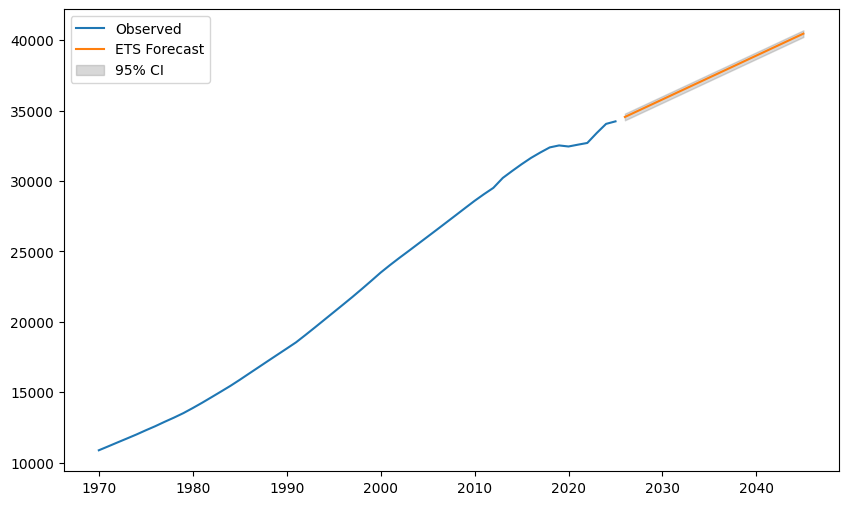

In [17]:
import matplotlib.pyplot as plt

sigma = ets.resid.std()

# 95% CI
lower = ets_forecast - 1.96 * sigma
upper = ets_forecast + 1.96 * sigma

plt.figure(figsize=(10,6))

plt.plot(malaysia_data, label='Observed')
plt.plot(ets_forecast, label='ETS Forecast')

plt.fill_between(
    ets_forecast.index,
    lower,
    upper,
    color='gray',
    alpha=0.3,
    label='95% CI'
)

plt.legend()
plt.show()


The confidence band is straight line, suggesting that ETS is deterministic and uncertainty is just residuals

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(ets.resid, lags=[10])

,lb_stat,lb_pvalue
10,13.99466,0.173235
